In [16]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog, local_binary_pattern   # <--- fix here
from skimage import exposure
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [28]:
DATASET_PATH = "dataset"

classes = ["Normal", "stone"]
label_map = {label: idx for idx, label in enumerate(classes)}

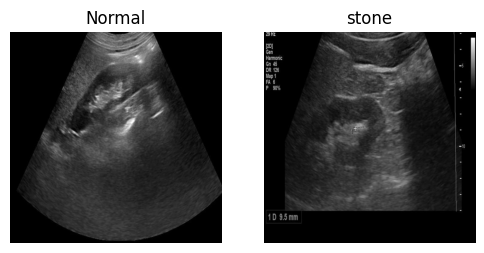

In [29]:
plt.figure(figsize=(6,3))

for i, cls in enumerate(classes):
    folder = os.path.join(DATASET_PATH, cls)
    img_name = os.listdir(folder)[0]
    img_path = os.path.join(folder, img_name)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(1,2,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(cls)
    plt.axis('off')

plt.show()


In [30]:
def preprocess_image(img):
    img = cv2.resize(img, (128, 128))
    img = cv2.GaussianBlur(img, (5, 5), 0)
    img = img / 255.0
    return img


In [31]:
def extract_features(img):
    features = []

    # 1) HOG features
    hog_features, hog_image = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=True
    )
    features.extend(hog_features)

    # 2) LBP features (texture)
    radius = 3
    n_points = 8 * radius
    lbp = local_binary_pattern(img, n_points, radius, method='uniform')
    # histogram of LBP patterns
    (lbp_hist, _) = np.histogram(lbp.ravel(),
                                 bins=np.arange(0, n_points + 3),
                                 range=(0, n_points + 2))
    lbp_hist = lbp_hist.astype("float")
    lbp_hist /= (lbp_hist.sum() + 1e-7)  # normalize
    features.extend(lbp_hist)

    # 3) Grayscale histogram (intensity)
    hist = cv2.calcHist([img.astype("float32")], [0], None, [32], [0, 1])
    hist = hist.flatten()
    hist /= (hist.sum() + 1e-7)
    features.extend(hist)

    return np.array(features), hog_image

In [ ]:
# -----------------------------
# Load dataset and extract features
# -----------------------------
X, y = [], []

for label in classes:
    folder = os.path.join(DATASET_PATH, label)
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = preprocess_image(img)
        features, _ = extract_features(img)
        X.append(features)
        y.append(label_map[label])

X = np.array(X)
y = np.array(y)
print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

# Show a part of the feature matrix
print("First 5 samples of X:\n", X[:5])
print("First 5 labels:\n", y[:5])

c:\Users\Somaya Ahmad\cv-projects\Kidney_stone_detection-\.venv\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


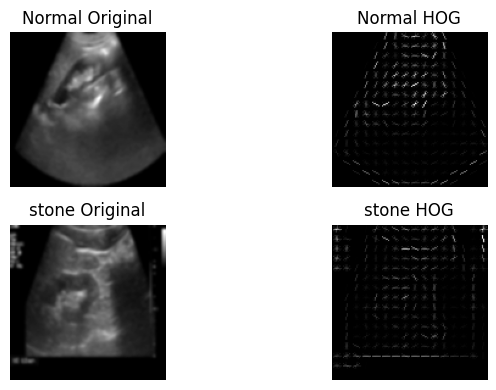

In [27]:
# -----------------------------
# Visualize HOG for first Normal and Stone image
# -----------------------------
plt.figure(figsize=(8,4))
for i, cls in enumerate(classes):
    folder = os.path.join(DATASET_PATH, cls)
    img_name = os.listdir(folder)[0]
    img_path = os.path.join(folder, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = preprocess_image(img)
    _, hog_image = extract_features(img)
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

    plt.subplot(2,2,i*2+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{cls} Original")
    plt.axis('off')

    plt.subplot(2,2,i*2+2)
    plt.imshow(hog_image_rescaled, cmap='gray')
    plt.title(f"{cls} HOG")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------
# Split data: 70% train, 15% val, 15% test
# -----------------------------
# split off 30% for temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

#  split temp into 50/50 → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (6591, 8158) (6591,)
Validation shape: (1412, 8158) (1412,)
Test shape: (1413, 8158) (1413,)


In [ ]:
# -----------------------------
# Train SVM classifier
# -----------------------------
clf = SVC(kernel='linear', probabilitTrain shape: (6591, 8158) (6591,)
Validation shape: (1412, 8158) (1412,)
Test shape: (1413, 8158) (1413,)y=True)
clf.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [25]:
# -----------------------------
# Evaluate on validation set
# -----------------------------
y_val_pred = clf.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))

Validation Accuracy: 1.0
Validation Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       662
           1       1.00      1.00      1.00       750

    accuracy                           1.00      1412
   macro avg       1.00      1.00      1.00      1412
weighted avg       1.00      1.00      1.00      1412

Validation Confusion Matrix:
 [[662   0]
 [  0 750]]


In [26]:
# -----------------------------
# Evaluate on test set
# -----------------------------
y_test_pred = clf.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Classification Report:\n", classification_report(y_test, y_test_pred))
print("Test Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

Test Accuracy: 1.0
Test Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       662
           1       1.00      1.00      1.00       751

    accuracy                           1.00      1413
   macro avg       1.00      1.00      1.00      1413
weighted avg       1.00      1.00      1.00      1413

Test Confusion Matrix:
 [[662   0]
 [  0 751]]
